# Pulsar Detection using Machine Learning

## Author: Hema Sri
## Project Type: Binary Classification  
## Dataset: HTRU2 Pulsar Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("HTRU_2.csv")
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [3]:
df.columns = [
    'Mean_IP',
    'Std_IP',
    'Kurtosis_IP',
    'Skewness_IP',
    'Mean_DM',
    'Std_DM',
    'Kurtosis_DM',
    'Skewness_DM',
    'Target'
]

df.head()

,Mean_IP,Std_IP,Kurtosis_IP,Skewness_IP,Mean_DM,Std_DM,Kurtosis_DM,Skewness_DM,Target
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Mean_IP      17897 non-null  float64
 1   Std_IP       17897 non-null  float64
 2   Kurtosis_IP  17897 non-null  float64
 3   Skewness_IP  17897 non-null  float64
 4   Mean_DM      17897 non-null  float64
 5   Std_DM       17897 non-null  float64
 6   Kurtosis_DM  17897 non-null  float64
 7   Skewness_DM  17897 non-null  float64
 8   Target       17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [5]:
df['Target'].value_counts()

Target
0    16258
1     1639
Name: count, dtype: int64

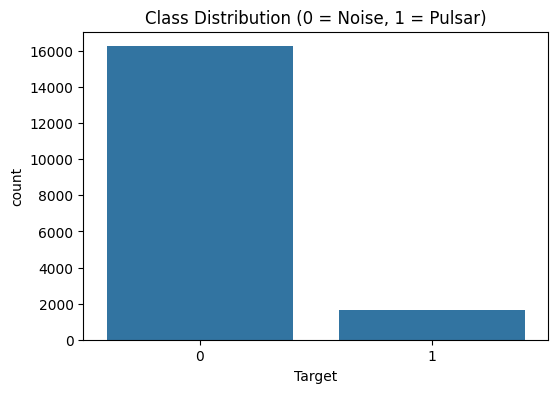

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title("Class Distribution (0 = Noise, 1 = Pulsar)")
plt.show()

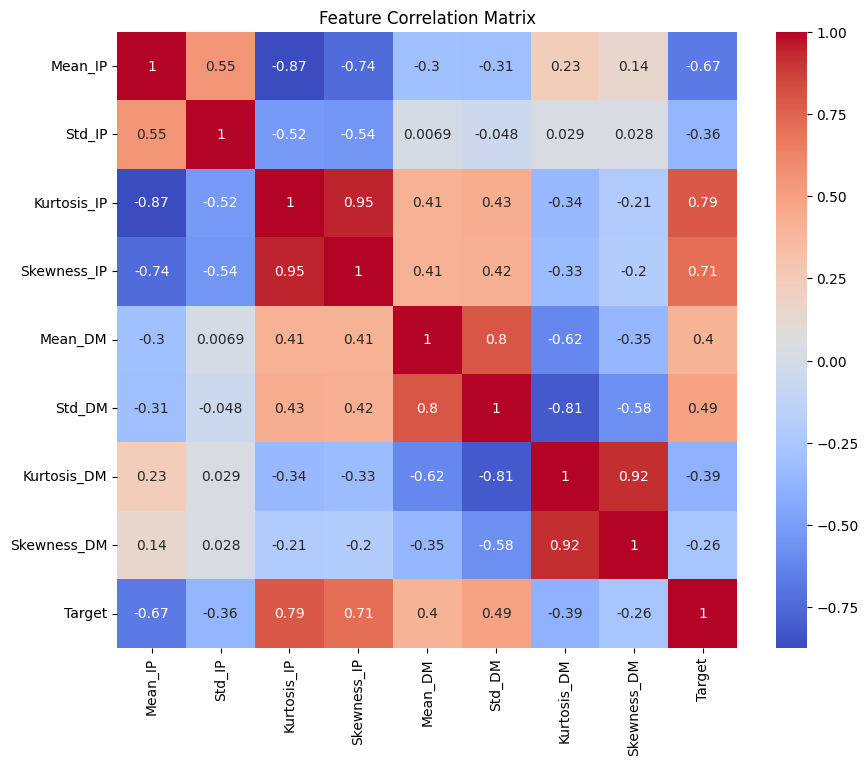

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
df.corr()['Target'].sort_values(ascending=False)

Target         1.000000
Kurtosis_IP    0.791592
Skewness_IP    0.709526
Std_DM         0.491532
Mean_DM        0.400873
Skewness_DM   -0.259123
Std_IP        -0.363704
Kurtosis_DM   -0.390819
Mean_IP       -0.673187
Name: Target, dtype: float64

In [10]:
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (14317, 8)
Testing size: (3580, 8)


In [12]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9798882681564246

Confusion Matrix:
 [[3243   16]
 [  56  265]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3259
           1       0.94      0.83      0.88       321

    accuracy                           0.98      3580
   macro avg       0.96      0.91      0.93      3580
weighted avg       0.98      0.98      0.98      3580



In [13]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.982122905027933

Confusion Matrix:
 [[3246   13]
 [  51  270]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3259
           1       0.95      0.84      0.89       321

    accuracy                           0.98      3580
   macro avg       0.97      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



In [14]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Kurtosis_IP    0.358504
Skewness_IP    0.208773
Mean_IP        0.164965
Std_DM         0.072302
Mean_DM        0.063327
Skewness_DM    0.048207
Std_IP         0.043794
Kurtosis_DM    0.040128
dtype: float64

In [16]:
sample_signal = pd.DataFrame(
    [[100, 50, 0.5, -0.4, 1.6, 14.8, 10.5, 120]],
    columns=X.columns
)

sample_signal_scaled = scaler.transform(sample_signal)

prediction = rf_model.predict(sample_signal_scaled)

print("Prediction:", prediction)

Prediction: [0]
